In [1]:
import databento as db
import polars as pl
import os

from dotenv import load_dotenv

from ohlc_dss_model import config

In [2]:
load_dotenv()

True

You can use whatever data provider you wanted for now I will be using databento

In [3]:
API_KEY = os.getenv("DATABENTO_API_KEY")
client = db.Historical(API_KEY)

In [4]:
start = "2016-01-01T00:00:00"
end = "2026-02-27T00:00:00"

In [ ]:
# data = client.timeseries.get_range(
#     dataset="GLBX.MDP3",
#     symbols=["NQ.c.0"],
#     stype_in="continuous",
#     schema="ohlcv-1m",
#     start=start,
#     end=end,
# )

/tmp/ipykernel_22868/637835632.py:1: BentoWarning: The streaming request contained one or more days which have reduced quality: 2017-11-13 (degraded), 2018-10-21 (degraded), 2019-01-15 (degraded)... See: https://databento.com/docs/api-reference-historical/metadata/metadata-get-dataset-condition
  data = client.timeseries.get_range(


In [9]:
pdf = data.to_df().reset_index()
df = pl.from_pandas(pdf)
print(df.columns)

['ts_event', 'rtype', 'publisher_id', 'instrument_id', 'open', 'high', 'low', 'close', 'volume', 'symbol']


In [10]:
df = df.rename({
    "ts_event": "DateTime",
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "volume": "Volume"
})

In [12]:
df.write_parquet(config.data.raw_folder_path / "nq_1m.parquet")

In [13]:
df_30m = (
    df.sort("DateTime")
    .group_by_dynamic("DateTime", every="30m")
    .agg([
        pl.col("Open").first(),
        pl.col("High").max(),
        pl.col("Low").min(),
        pl.col("Close").last(),
        pl.col("Volume").sum(),
    ])
)

In [14]:
df_30m.write_parquet(config.data.raw_folder_path / "nq_30m.parquet")

In [15]:
df_30m.head(5)

DateTime,Open,High,Low,Close,Volume
"datetime[ns, UTC]",f64,f64,f64,f64,u64
2016-01-03 23:00:00 UTC,4592.5,4606.75,4592.5,4603.25,1134
2016-01-03 23:30:00 UTC,4603.0,4603.0,4597.5,4600.5,425
2016-01-04 00:00:00 UTC,4600.25,4604.0,4599.75,4604.0,477
2016-01-04 00:30:00 UTC,4603.5,4604.25,4602.25,4603.75,331
2016-01-04 01:00:00 UTC,4603.75,4605.5,4598.75,4599.0,555


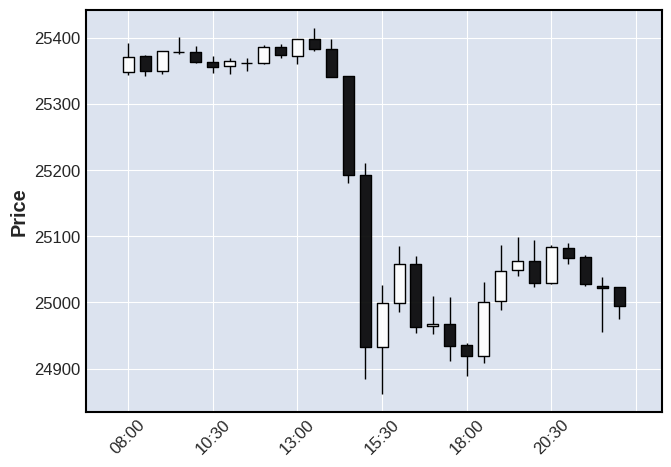

In [18]:
import mplfinance as mpf

last_15 = df_30m.tail(30).to_pandas()
last_15 = last_15.set_index("DateTime")

mpf.plot(last_15, type="candle")

It loaded correctly we can move on